# Análisis de perfil y desempeño 01/06/2026

# Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from datetime import date
import scipy.stats as stats
import numpy as np
import plotly.graph_objs as go

# Funciones

In [2]:
def distr_hist(df: pd.DataFrame, column: str, bars: int) -> None:
    """
    Muestra un histograma para una columna del DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    column : str
        Columna a visualizar.
    bars : int
        Número de barras del histograma.
    """
    plt.hist(df[column], bins=bars)
    plt.title(f'Distribución de la variable {column}')
    plt.show()

In [3]:
def distr_value(df: pd.DataFrame, column: str) -> None:
    """
    Muestra la distribución porcentual y los valores únicos de una columna.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    column : str
        Columna a analizar.
    """
    value_count = df[column].value_counts(normalize=True)*100
    print(f'Value counts: {value_count}')
    val_unique = df[column].unique()
    print(f'----\nValores únicos:{val_unique}')
    
    print('----\nGráfico distribución valores únicos:')
    (df[column]
    .value_counts(normalize=True)
    .mul(100)
    .plot(kind='bar'))

    plt.ylabel('Porcentaje (%)')
    plt.xlabel('Hit_target')
    plt.title('Distribución de Hit_target')
    plt.show()                  

In [4]:
def distr_boxplot(df: pd.DataFrame, column: str) -> None:
    """
    Muestra un boxplot para una columna del DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    column : str
        Columna a visualizar.
    """
    plt.boxplot(df[column])
    plt.title(f'Boxplot de la variable {column}')
    plt.show()

In [5]:
def outliers_column(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Devuelve las filas con valores atípicos en una columna usando el método IQR.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    column : str
        Columna numérica a analizar.
    """
    col = df[column]

    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1

    limit_inferior = Q1 - 1.5 * IQR
    limit_superior = Q3 + 1.5 * IQR

    outliers = df[(col < limit_inferior) | (col > limit_superior)]
    
    return outliers

# Documento

In [6]:
df_RRHH = pd.read_csv('../../Data/clean/clean_data_01062026.csv')
df_RRHH

,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,...,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours,importacion
0,14,11.0,Sistema digestivo,5.0,Mayo,2,Lunes,2,Primavera,155,...,2,1,0,0,95,196,25,24.7,120,2026-05-25
1,36,13.0,Sistema musculoesquelético,10.0,Octubre,4,Miércoles,4,Otoño,118,...,1,1,0,0,98,178,31,30.9,120,2026-05-25
2,9,6.0,Sistema nervioso,1.0,Enero,3,Martes,1,Invierno,228,...,2,0,0,1,65,172,22,22.0,120,2026-05-25
3,28,9.0,Sistema circulatorio,1.0,Enero,3,Martes,1,Invierno,225,...,1,0,0,2,69,169,24,24.2,112,2026-05-25
4,9,12.0,Piel y tejido subcutáneo,9.0,Septiembre,3,Martes,3,Verano,228,...,2,0,0,1,65,172,22,22.0,112,2026-05-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839,14,11.0,Sistema digestivo,5.0,Mayo,2,Lunes,2,Primavera,155,...,2,1,0,0,95,196,25,24.7,120,2026-06-01
840,36,13.0,Sistema musculoesquelético,10.0,Octubre,4,Miércoles,4,Otoño,118,...,1,1,0,0,98,178,31,30.9,120,2026-06-01
841,9,6.0,Sistema nervioso,1.0,Enero,3,Martes,1,Invierno,228,...,2,0,0,1,65,172,22,22.0,120,2026-06-01
842,28,9.0,Sistema circulatorio,1.0,Enero,3,Martes,1,Invierno,225,...,1,0,0,2,69,169,24,24.2,112,2026-06-01


In [7]:
df_RRHH.info()

<class 'pandas.DataFrame'>
RangeIndex: 844 entries, 0 to 843
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       844 non-null    int64  
 1   Reason_absence           802 non-null    float64
 2   Reason_absence_name      802 non-null    str    
 3   Month_absence            841 non-null    float64
 4   Month_absence_name       841 non-null    str    
 5   Day_week                 844 non-null    int64  
 6   Day_week_name            844 non-null    str    
 7   Seasons                  844 non-null    int64  
 8   Seasons_name             844 non-null    str    
 9   Transportation_expense   844 non-null    int64  
 10  Distance_Residence_Work  844 non-null    int64  
 11  Service_time             844 non-null    int64  
 12  Age                      844 non-null    int64  
 13  Work_load_Average_day    844 non-null    float64
 14  Hit_target               844 non-null

In [8]:
df_RRHH.shape

(844, 28)

In [9]:
df_RRHH.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,844.0,26.125592,26.389515,1.000,10.000,20.000,33.000,136.000
Reason_absence,802.0,20.314214,7.176987,1.000,13.000,23.000,27.000,28.000
Month_absence,841.0,6.527943,3.400209,1.000,4.000,7.000,9.000,12.000
Day_week,844.0,3.928910,1.416617,2.000,3.000,4.000,5.000,6.000
Seasons,844.0,2.523697,1.095946,1.000,2.000,3.000,3.000,4.000
Transportation_expense,844.0,220.477488,67.456296,118.000,179.000,225.000,260.000,388.000
Distance_Residence_Work,844.0,29.422986,14.748504,5.000,16.000,26.000,49.000,52.000
Service_time,844.0,12.582938,4.425366,1.000,9.000,12.500,16.000,29.000
Age,844.0,36.453791,6.552751,27.000,31.000,37.000,40.000,58.000
Work_load_Average_day,844.0,271.957630,39.054208,205.917,244.387,264.604,294.217,378.884


In [10]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
       'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
       'Seasons_name', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
       'Disciplinary_failure', 'Education', 'Education_name', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
       'Body_mass_index', 'BMI_calculated', 'Absenteeism_hours',
       'importacion'],
      dtype='str')

Listas de columnas numéricas y categóricas separadas de todo el dataset (con 'ID')

In [11]:
num = ['ID','Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Work_load_Average_day', 'Hit_target','Pet', 'Son',
       'Weight', 'Height', 'Absenteeism_hours', 'BMI_calculated']

cat = ['ID','Reason_absence', 'Month_absence', 'Day_week',
       'Seasons', 'Disciplinary_failure', 'Education',
       'Social_drinker', 'Social_smoker']

## Tamaño de muestra

In [12]:
df_RRHH.info()

<class 'pandas.DataFrame'>
RangeIndex: 844 entries, 0 to 843
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       844 non-null    int64  
 1   Reason_absence           802 non-null    float64
 2   Reason_absence_name      802 non-null    str    
 3   Month_absence            841 non-null    float64
 4   Month_absence_name       841 non-null    str    
 5   Day_week                 844 non-null    int64  
 6   Day_week_name            844 non-null    str    
 7   Seasons                  844 non-null    int64  
 8   Seasons_name             844 non-null    str    
 9   Transportation_expense   844 non-null    int64  
 10  Distance_Residence_Work  844 non-null    int64  
 11  Service_time             844 non-null    int64  
 12  Age                      844 non-null    int64  
 13  Work_load_Average_day    844 non-null    float64
 14  Hit_target               844 non-null

In [13]:
# Función para calcular la moda de variables categóricas/temporales
def moda(x):
    m = x.dropna().mode()
    return m.iloc[0] if len(m) > 0 else np.nan

df_emp = df_RRHH.groupby('ID').agg(
    # Variable dependiente agregada a nivel empleado
    Hit_target_median=('Hit_target', 'median'),
    Hit_target_mean=('Hit_target', 'mean'),

    # Número de solicitudes / registros de ausencia por empleado
    num_absences=('ID', 'size'),

    # Variables numéricas del empleado
    Age=('Age', 'first'),
    Service_time=('Service_time', 'first'),
    Distance_Residence_Work=('Distance_Residence_Work', 'first'),
    Transportation_expense=('Transportation_expense', 'first'),

    # Variables que pueden variar por registro
    Absenteeism_hours_total=('Absenteeism_hours', 'sum'),
    Absenteeism_hours_median=('Absenteeism_hours', 'median'),
    # Work_load_Average_day_median=('Work_load_Average_day', 'median'),

    # Variables categóricas/dummy del empleado
    Disciplinary_failure=('Disciplinary_failure', 'first'),
    Education=('Education', 'first'),
    Son=('Son', 'first'),
    Social_drinker=('Social_drinker', 'first'),
    Social_smoker=('Social_smoker', 'first'),
    Pet=('Pet', 'first'),

    # Variables temporales: valor más frecuente por empleado
    Month_absence_mode=('Month_absence', moda),
    Seasons_mode=('Seasons', moda)
).reset_index()

In [14]:
variables_grupo = [
    'Disciplinary_failure',
    'Education',
    'Son',
    'Social_drinker',
    'Social_smoker',
    'Pet'
]

for var in variables_grupo:
    #print(f"\n{var}")
    print(df_emp[var].value_counts(dropna=False))
    print(df_emp[var].value_counts(normalize=True, dropna=False) * 100)

Disciplinary_failure
0    135
1      1
Name: count, dtype: int64
Disciplinary_failure
0    99.264706
1     0.735294
Name: proportion, dtype: float64
Education
1    114
3     12
2      9
4      1
Name: count, dtype: int64
Education
1    83.823529
3     8.823529
2     6.617647
4     0.735294
Name: proportion, dtype: float64
Son
0    59
1    41
2    28
3     5
4     3
Name: count, dtype: int64
Son
0    43.382353
1    30.147059
2    20.588235
3     3.676471
4     2.205882
Name: proportion, dtype: float64
Social_drinker
1    71
0    65
Name: count, dtype: int64
Social_drinker
1    52.205882
0    47.794118
Name: proportion, dtype: float64
Social_smoker
0    122
1     14
Name: count, dtype: int64
Social_smoker
0    89.705882
1    10.294118
Name: proportion, dtype: float64
Pet
0    83
1    24
2    21
4     5
8     2
5     1
Name: count, dtype: int64
Pet
0    61.029412
1    17.647059
2    15.441176
4     3.676471
8     1.470588
5     0.735294
Name: proportion, dtype: float64


## df individuo (df_RRHH_ind_grouped)
**df_RRHH_ind_grouped** con:
- Variables sociodemográficas de cada individuo agrupadas
- Mediana de work_load_average_day y de hit target
- Conteo del número de ausencias (count de las solicitudes que tienen más de 0 horas)
- Sma de horas de absentismo.

In [15]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
       'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
       'Seasons_name', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
       'Disciplinary_failure', 'Education', 'Education_name', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
       'Body_mass_index', 'BMI_calculated', 'Absenteeism_hours',
       'importacion'],
      dtype='str')

In [16]:
df_RRHH_ind = df_RRHH[[
        'ID', 'Transportation_expense', 'Distance_Residence_Work',
        'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
        'Disciplinary_failure', 'Education', 'Education_name', 'Son',
        'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
        'BMI_calculated', 'Absenteeism_hours',
        ]].copy()

In [17]:
df_RRHH_ind.shape

(844, 18)

In [18]:
df_RRHH_ind.sample(5)

,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,BMI_calculated,Absenteeism_hours
173,5,235,20,13,43,330.061,100,0,1,Secundaria,1,1,0,0,106,167,38.0,8
579,33,248,25,14,47,222.196,99,0,1,Secundaria,2,0,0,1,86,165,31.6,2
504,3,179,51,18,38,236.629,93,0,1,Secundaria,0,1,0,0,89,170,30.8,2
592,22,179,26,9,30,246.288,91,0,3,Posgrado,0,0,0,0,56,171,19.2,2
107,17,179,22,17,40,343.253,95,0,2,Grado,2,0,1,0,63,170,21.8,8


In [19]:
cols_first = [
    'Transportation_expense', 'Distance_Residence_Work',
    'Service_time', 'Age',
    'Disciplinary_failure', 'Education', 'Education_name', 'Son',
    'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
    'BMI_calculated'
]

df_RRHH_ind_grouped = (
    df_RRHH_ind
    .groupby('ID')
    .agg(
        **{col: (col, 'first') for col in cols_first},
        Work_load_Average_day=('Work_load_Average_day', 'median'),
        Hit_target=('Hit_target', 'median'),
        Absenteeism_hours=('Absenteeism_hours', 'sum'),
        Absence_count=('Absenteeism_hours', lambda x: (x > 0).sum())
    )
    .reset_index()
)

df_RRHH_ind_grouped[['Work_load_Average_day', 'Hit_target']] = (
    df_RRHH_ind_grouped[['Work_load_Average_day', 'Hit_target']]
    .round(3)
)

In [20]:
df_RRHH_ind_grouped

,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Disciplinary_failure,Education,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,BMI_calculated,Work_load_Average_day,Hit_target,Absenteeism_hours,Absence_count
0,1,235,11,14,37,0,3,Posgrado,1,0,0,1,88,172,29.7,249.797,95.0,121,22
1,2,235,29,12,48,0,1,Secundaria,1,0,1,5,88,163,33.1,218.104,92.0,25,4
2,3,179,51,18,38,0,1,Secundaria,0,1,0,0,89,170,30.8,253.465,96.0,482,112
3,4,118,14,13,40,0,1,Secundaria,1,1,0,8,98,170,33.9,271.219,95.0,0,0
4,5,235,20,13,43,0,1,Secundaria,1,1,0,0,106,167,38.0,265.017,93.0,104,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,132,118,13,18,50,0,1,Secundaria,1,1,0,0,98,178,30.9,244.387,98.0,3,1
132,133,118,10,10,37,0,1,Secundaria,0,0,0,0,83,172,28.1,241.476,92.0,3,1
133,134,118,10,10,37,0,1,Secundaria,0,0,0,0,83,172,28.1,268.519,93.0,8,1
134,135,225,26,9,28,0,1,Secundaria,1,0,0,2,69,169,24.2,378.884,92.0,8,1


In [21]:
df_RRHH_ind_grouped.columns

Index(['ID', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Disciplinary_failure', 'Education',
       'Education_name', 'Son', 'Social_drinker', 'Social_smoker', 'Pet',
       'Weight', 'Height', 'BMI_calculated', 'Work_load_Average_day',
       'Hit_target', 'Absenteeism_hours', 'Absence_count'],
      dtype='str')

Listas de columnas numéricas y categóricas separadas para el estudio de individuo (_ID)

In [22]:
num_ID = ['ID','Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Pet', 'Son', 'Weight', 'Height', 'BMI_calculated','Work_load_Average_day',
       'Hit_target', 'Absenteeism_hours', 'Absence_count']

cat_ID = ['ID','Disciplinary_failure', 'Education',
       'Social_drinker', 'Social_smoker']

## df ausencias sin variables sociodemográficas (df_RRHH_abs)
**df_RRHH_abs**  
Variables asociadas directamente con la solicitud de ausencia

In [23]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
       'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
       'Seasons_name', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
       'Disciplinary_failure', 'Education', 'Education_name', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
       'Body_mass_index', 'BMI_calculated', 'Absenteeism_hours',
       'importacion'],
      dtype='str')

In [24]:
col_absence = [
    'ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
    'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
    'Seasons_name', 'Work_load_Average_day', 'Hit_target', 'Absenteeism_hours'
]

In [25]:
df_RRHH_abs = df_RRHH[col_absence].copy()

df_RRHH_abs

,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Work_load_Average_day,Hit_target,Absenteeism_hours
0,14,11.0,Sistema digestivo,5.0,Mayo,2,Lunes,2,Primavera,284.031,97,120
1,36,13.0,Sistema musculoesquelético,10.0,Octubre,4,Miércoles,4,Otoño,239.409,98,120
2,9,6.0,Sistema nervioso,1.0,Enero,3,Martes,1,Invierno,264.604,93,120
3,28,9.0,Sistema circulatorio,1.0,Enero,3,Martes,1,Invierno,230.290,92,112
4,9,12.0,Piel y tejido subcutáneo,9.0,Septiembre,3,Martes,3,Verano,222.196,99,112
...,...,...,...,...,...,...,...,...,...,...,...,...
839,14,11.0,Sistema digestivo,5.0,Mayo,2,Lunes,2,Primavera,284.031,97,120
840,36,13.0,Sistema musculoesquelético,10.0,Octubre,4,Miércoles,4,Otoño,239.409,98,120
841,9,6.0,Sistema nervioso,1.0,Enero,3,Martes,1,Invierno,264.604,93,120
842,28,9.0,Sistema circulatorio,1.0,Enero,3,Martes,1,Invierno,230.290,92,112


# Pregunta de negocio

**Analista de Perfil i Desempeño Professional:**  
- Quines característiques dels empleats estan associades amb un millor acompliment laboral
- com podem utilitzar aquesta informació per dissenyar estratègies de selecció, capacitació i retenció més efectives?

## Análisis descriptivo

### Distribución variable hit target (histograma y boxplot [outliers])

Distribución sin agrupar por individuo (de solicitudes)

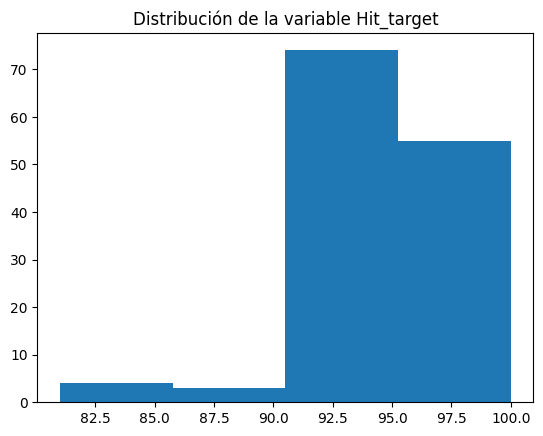

In [26]:
distr_hist(df_RRHH_ind_grouped,'Hit_target',4)

Value counts: Hit_target
93.0     15.441176
95.0     14.705882
99.0     13.235294
96.0     10.294118
91.0      8.823529
92.0      8.088235
97.0      8.088235
98.0      5.882353
94.0      5.882353
81.0      2.941176
88.0      1.470588
96.5      1.470588
94.5      0.735294
93.5      0.735294
97.5      0.735294
100.0     0.735294
87.0      0.735294
Name: proportion, dtype: float64
----
Valores únicos:[ 95.   92.   96.   93.   94.5  88.   96.5  93.5  91.   97.5  98.   94.
  97.   99.  100.   81.   87. ]
----
Gráfico distribución valores únicos:


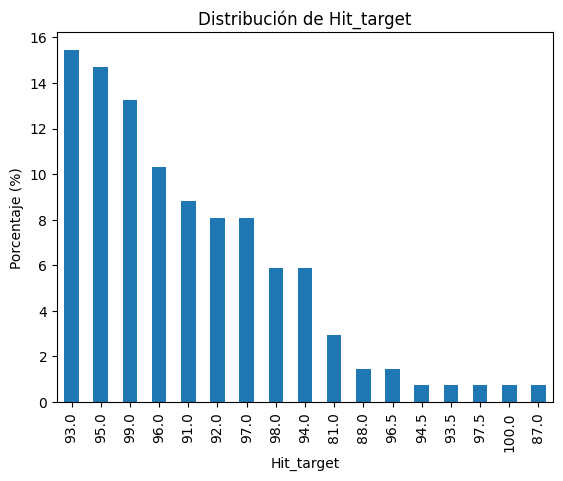

In [27]:
distr_value(df_RRHH_ind_grouped,'Hit_target')

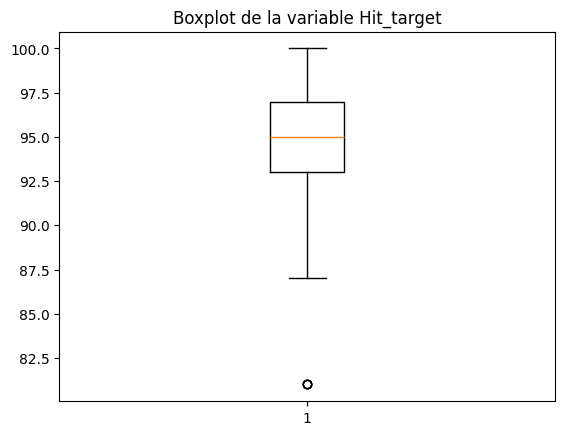

In [28]:
distr_boxplot(df_RRHH_ind_grouped,'Hit_target')

Para saber el valor del outlier he mirado qué valores quedan fuera del cuartil Q1 y Q3.  
El valor **outlier es 81** (hay 23 registros), que es el mínimo, el siguiente valor es 88.

In [29]:
outliers_hit_target_all = outliers_column(df_RRHH,'Hit_target')
outliers_hit_target_all

,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,...,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours,importacion
20,15,7.0,Ojo y anexos,3.0,Marzo,2,Lunes,2,Primavera,291,...,1,1,0,1,73,171,25,25.0,40,2026-05-25
25,24,9.0,Sistema circulatorio,3.0,Marzo,4,Miércoles,1,Invierno,246,...,0,1,0,0,67,170,23,23.2,32,2026-05-25
36,11,19.0,"Lesiones, intoxicaciones y consecuencias externas",3.0,Marzo,4,Miércoles,1,Invierno,289,...,2,1,0,1,90,172,30,30.4,24,2026-05-25
52,24,9.0,Sistema circulatorio,3.0,Marzo,2,Lunes,1,Invierno,246,...,0,1,0,0,67,170,23,23.2,16,2026-05-25
148,3,11.0,Sistema digestivo,3.0,Marzo,2,Lunes,1,Invierno,179,...,0,1,0,0,89,170,31,30.8,8,2026-05-25
149,3,13.0,Sistema musculoesquelético,3.0,Marzo,4,Miércoles,1,Invierno,179,...,0,1,0,0,89,170,31,30.8,8,2026-05-25
150,5,26.0,Ausencia injustificada,3.0,Marzo,4,Miércoles,2,Primavera,235,...,1,1,0,0,106,167,38,38.0,8,2026-05-25
151,3,13.0,Sistema musculoesquelético,3.0,Marzo,2,Lunes,2,Primavera,179,...,0,1,0,0,89,170,31,30.8,8,2026-05-25
301,15,28.0,Consulta dental,3.0,Marzo,6,Viernes,1,Invierno,291,...,1,1,0,1,73,171,25,25.0,4,2026-05-25
302,20,28.0,Consulta dental,3.0,Marzo,6,Viernes,1,Invierno,260,...,4,1,0,0,65,168,23,23.0,4,2026-05-25


Distribución agrupada por individuo

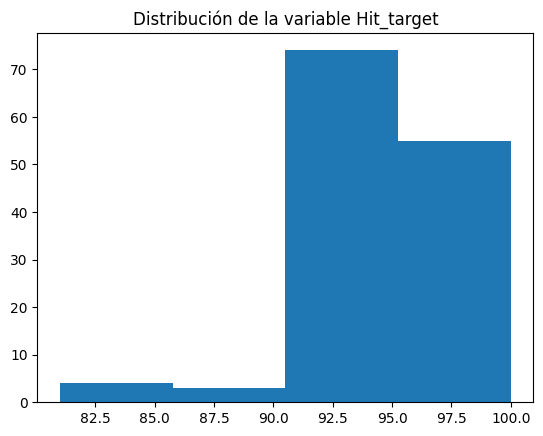

In [30]:
distr_hist(df_RRHH_ind_grouped,'Hit_target',4)

Value counts: Hit_target
93.0     15.441176
95.0     14.705882
99.0     13.235294
96.0     10.294118
91.0      8.823529
92.0      8.088235
97.0      8.088235
98.0      5.882353
94.0      5.882353
81.0      2.941176
88.0      1.470588
96.5      1.470588
94.5      0.735294
93.5      0.735294
97.5      0.735294
100.0     0.735294
87.0      0.735294
Name: proportion, dtype: float64
----
Valores únicos:[ 95.   92.   96.   93.   94.5  88.   96.5  93.5  91.   97.5  98.   94.
  97.   99.  100.   81.   87. ]
----
Gráfico distribución valores únicos:


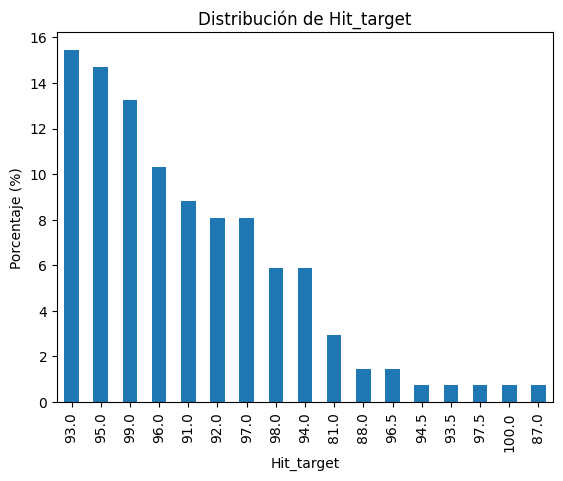

In [31]:
distr_value(df_RRHH_ind_grouped,'Hit_target')

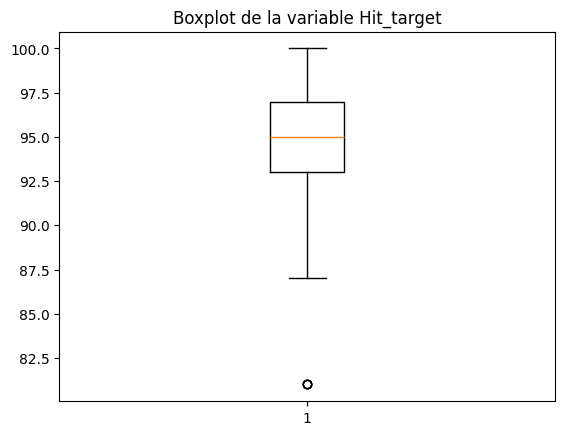

In [32]:
distr_boxplot(df_RRHH_ind_grouped,'Hit_target')

Para saber el valor del outlier he mirado qué valores quedan fuera del cuartil Q1 y Q3.  
El valor **outlier es 81** (hay 23 registros), que es el mínimo, el siguiente valor es 88.

In [33]:
outliers_hit_target_all = outliers_column(df_RRHH,'Hit_target')
outliers_hit_target_all

,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,...,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours,importacion
20,15,7.0,Ojo y anexos,3.0,Marzo,2,Lunes,2,Primavera,291,...,1,1,0,1,73,171,25,25.0,40,2026-05-25
25,24,9.0,Sistema circulatorio,3.0,Marzo,4,Miércoles,1,Invierno,246,...,0,1,0,0,67,170,23,23.2,32,2026-05-25
36,11,19.0,"Lesiones, intoxicaciones y consecuencias externas",3.0,Marzo,4,Miércoles,1,Invierno,289,...,2,1,0,1,90,172,30,30.4,24,2026-05-25
52,24,9.0,Sistema circulatorio,3.0,Marzo,2,Lunes,1,Invierno,246,...,0,1,0,0,67,170,23,23.2,16,2026-05-25
148,3,11.0,Sistema digestivo,3.0,Marzo,2,Lunes,1,Invierno,179,...,0,1,0,0,89,170,31,30.8,8,2026-05-25
149,3,13.0,Sistema musculoesquelético,3.0,Marzo,4,Miércoles,1,Invierno,179,...,0,1,0,0,89,170,31,30.8,8,2026-05-25
150,5,26.0,Ausencia injustificada,3.0,Marzo,4,Miércoles,2,Primavera,235,...,1,1,0,0,106,167,38,38.0,8,2026-05-25
151,3,13.0,Sistema musculoesquelético,3.0,Marzo,2,Lunes,2,Primavera,179,...,0,1,0,0,89,170,31,30.8,8,2026-05-25
301,15,28.0,Consulta dental,3.0,Marzo,6,Viernes,1,Invierno,291,...,1,1,0,1,73,171,25,25.0,4,2026-05-25
302,20,28.0,Consulta dental,3.0,Marzo,6,Viernes,1,Invierno,260,...,4,1,0,0,65,168,23,23.0,4,2026-05-25


## Correlación Spearman (solo del agrupado)

## Test no paramétricos (solo del agrupado)

### Mann Whitney

#### Variables a categorizar

##### Absence count

In [103]:
df_RRHH_ind_grouped['Absence_count'].value_counts(normalize=True).sort_index()

Absence_count
0      0.022059
1      0.735294
2      0.029412
4      0.022059
5      0.022059
6      0.007353
7      0.014706
8      0.007353
10     0.014706
13     0.007353
14     0.014706
20     0.007353
22     0.007353
23     0.007353
24     0.007353
29     0.014706
30     0.007353
35     0.007353
38     0.007353
39     0.007353
46     0.007353
54     0.007353
76     0.007353
112    0.007353
Name: proportion, dtype: float64

In [104]:
df_abs_count_hit_target = df_RRHH_ind_grouped[['ID','Absence_count','Hit_target']].copy()
df_abs_count_hit_target

,ID,Absence_count,Hit_target
0,1,22,95.0
1,2,4,92.0
2,3,112,96.0
3,4,0,95.0
4,5,14,93.0
...,...,...,...
131,132,1,98.0
132,133,1,92.0
133,134,1,93.0
134,135,1,92.0


In [105]:
df_abs_count_hit_target['category'] = np.where(
    df_abs_count_hit_target['Absence_count'] == 1,
    '1 ausencia',
    '>1 ausencias'
)

In [106]:
df_abs_count_hit_target['category'].value_counts()

category
1 ausencia      100
>1 ausencias     36
Name: count, dtype: int64

In [107]:
group_1 = df_abs_count_hit_target.loc[
    df_abs_count_hit_target['category'] == '1 ausencia',
    'Hit_target'
]

group_more_1 = df_abs_count_hit_target.loc[
    df_abs_count_hit_target['category'] == '>1 ausencias',
    'Hit_target'
]

u_statistic, p_value = stats.mannwhitneyu(
    group_1,
    group_more_1,
    alternative='two-sided'
)

print(f'U statistic: {u_statistic}')
print(f'p-value: {p_value}')

if p_value < 0.05:
    print('Reject H0: hay diferencias estadísticamente significativas entre los grupos.')
else:
    print('Fail to reject H0: no hay diferencias estadísticamente significativas entre los grupos.')

U statistic: 1776.5
p-value: 0.9091102720298745
Fail to reject H0: no hay diferencias estadísticamente significativas entre los grupos.


##### Son

In [120]:
df_RRHH_ind_grouped['Son'].value_counts(normalize=True).sort_index()

Son
0    0.433824
1    0.301471
2    0.205882
3    0.036765
4    0.022059
Name: proportion, dtype: float64

In [122]:
df_son_hit_target = df_RRHH_ind_grouped[['ID','Son','Hit_target']].copy()
df_son_hit_target

,ID,Son,Hit_target
0,1,1,95.0
1,2,1,92.0
2,3,0,96.0
3,4,1,95.0
4,5,1,93.0
...,...,...,...
131,132,1,98.0
132,133,0,92.0
133,134,0,93.0
134,135,1,92.0


0 no tiene hijos y 1 sí que tiene

In [123]:
df_son_hit_target['category'] = np.where(
    df_son_hit_target['Son'] == 0,
    '0',
    '1'
)

In [125]:
df_son_hit_target['category'].value_counts()

category
1    77
0    59
Name: count, dtype: int64

In [126]:
group_0 = df_son_hit_target.loc[
    df_son_hit_target['category'] == '0',
    'Hit_target'
]

group_1 = df_son_hit_target.loc[
    df_son_hit_target['category'] == '1',
    'Hit_target'
]

u_statistic, p_value = stats.mannwhitneyu(
    group_0,
    group_1,
    alternative='two-sided'
)

print(f'U statistic: {u_statistic}')
print(f'p-value: {p_value}')

if p_value < 0.05:
    print('Reject H0: hay diferencias estadísticamente significativas entre los grupos.')
else:
    print('Fail to reject H0: no hay diferencias estadísticamente significativas entre los grupos.')

U statistic: 2405.0
p-value: 0.5567652371806612
Fail to reject H0: no hay diferencias estadísticamente significativas entre los grupos.


##### Pet

In [127]:
df_RRHH_ind_grouped['Pet'].value_counts(normalize=True).sort_index()

Pet
0    0.610294
1    0.176471
2    0.154412
4    0.036765
5    0.007353
8    0.014706
Name: proportion, dtype: float64

In [128]:
df_pet_hit_target = df_RRHH_ind_grouped[['ID','Pet','Hit_target']].copy()
df_pet_hit_target

,ID,Pet,Hit_target
0,1,1,95.0
1,2,5,92.0
2,3,0,96.0
3,4,8,95.0
4,5,0,93.0
...,...,...,...
131,132,0,98.0
132,133,0,92.0
133,134,0,93.0
134,135,2,92.0


0 no tiene perros y 1 sí que tiene

In [131]:
df_pet_hit_target['category'] = np.where(
    df_pet_hit_target['Pet'] == 0,
    '0',
    '1'
)

In [132]:
df_son_hit_target['category'].value_counts()

category
1    77
0    59
Name: count, dtype: int64

In [133]:
group_0 = df_pet_hit_target.loc[
    df_pet_hit_target['category'] == '0',
    'Hit_target'
]

group_1 = df_pet_hit_target.loc[
    df_pet_hit_target['category'] == '1',
    'Hit_target'
]

u_statistic, p_value = stats.mannwhitneyu(
    group_0,
    group_1,
    alternative='two-sided'
)

print(f'U statistic: {u_statistic}')
print(f'p-value: {p_value}')

if p_value < 0.05:
    print('Reject H0: hay diferencias estadísticamente significativas entre los grupos.')
else:
    print('Fail to reject H0: no hay diferencias estadísticamente significativas entre los grupos.')

U statistic: 2492.0
p-value: 0.1898130395173192
Fail to reject H0: no hay diferencias estadísticamente significativas entre los grupos.


### Kruskall-Wallis test  
[Kruskal Wallis test in Python - Medium](https://tnathu-ai.medium.com/kruskal-wallis-test-in-python-2899a3c87a8b)

In [56]:
def kruskal_wallis_test(*groups, alpha=0.05, group_names=None):
    """
    Performs the Kruskal-Wallis test for 3 or more independent groups
    and prints descriptive statistics and test results.
    """

    if len(groups) < 3:
        raise ValueError("Kruskal-Wallis test requires at least 3 groups.")

    if group_names is None:
        group_names = [f'Group {i+1}' for i in range(len(groups))]

    if len(group_names) != len(groups):
        raise ValueError("group_names must have the same length as groups.")

    k = len(groups)
    degree_freedom = k - 1

    upper_tail_critical_value = stats.chi2.ppf(
        1 - alpha,
        df=degree_freedom
    )

    h_statistic, p_value = stats.kruskal(*groups)

    descriptors = []

    for name, group in zip(group_names, groups):
        group_series = pd.Series(group)

        q1 = group_series.quantile(0.25)
        q3 = group_series.quantile(0.75)

        descriptors.append({
            'group': name,
            'n': group_series.count(),
            'mean': group_series.mean(),
            'median': group_series.median(),
            'std': group_series.std(),
            'min': group_series.min(),
            'max': group_series.max(),
            'q1': q1,
            'q3': q3,
            'iqr': q3 - q1
        })

    descriptors_df = pd.DataFrame(descriptors)

    print('Descriptive statistics:')
    display(descriptors_df)

    print('\n---- Kruskal-Wallis test ----')
    print(f'Number of groups: {k}')
    print(f'Degrees of freedom: {degree_freedom}')
    print(f'Alpha: {alpha}')
    print(f'H statistic: {h_statistic}')
    print(f'P-value: {p_value}')
    print(f'Critical value X²U: {upper_tail_critical_value}')

    print('\n---- Interpretation using p-value ----')

    if p_value < alpha:
        print(
            f"The p-value is less than alpha {alpha}, so the result is significant.\n"
            "Reject the null hypothesis: at least one group is statistically different."
        )
    else:
        print(
            f"The p-value is larger than alpha {alpha}, so the result is not significant.\n"
            "Fail to reject the null hypothesis: there is no statistically significant difference between groups."
        )

    print('\n---- Interpretation using H statistic ----')

    if h_statistic < upper_tail_critical_value:
        print(
            "The Kruskal-Wallis H statistic is smaller than the critical value.\n"
            "Fail to reject the null hypothesis."
        )
    else:
        print(
            "The Kruskal-Wallis H statistic is larger than the critical value.\n"
            "Reject the null hypothesis."
        )

In [34]:
df_RRHH_ind_grouped.columns

Index(['ID', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Disciplinary_failure', 'Education',
       'Education_name', 'Son', 'Social_drinker', 'Social_smoker', 'Pet',
       'Weight', 'Height', 'BMI_calculated', 'Work_load_Average_day',
       'Hit_target', 'Absenteeism_hours', 'Absence_count'],
      dtype='str')

#### Variables directas

In [ ]:
vars_estudio = [
              'Education', 'Son','Pet'
              ]



##### Hit target Vs Education

In [44]:
col_unique_values = sorted(df_RRHH_ind_grouped['Education'].unique().tolist())

# df_value = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Education'] == value]

print(col_unique_values)

[1, 2, 3, 4]


Crear grupos

In [53]:
df_education_1 = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Education'] == 1]['Hit_target']
df_education_2 = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Education'] == 2]['Hit_target']
df_education_3 = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Education'] == 3]['Hit_target']
df_education_4 = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Education'] == 4]['Hit_target']

Comprovar grupo 1 (como ejemplo)

In [52]:
df_education_1

1      92.0
2      96.0
3      95.0
4      93.0
5      94.5
       ... 
131    98.0
132    92.0
133    93.0
134    92.0
135    98.0
Name: Hit_target, Length: 114, dtype: float64

Comprovar el tamaño de cada uno

In [54]:
print(df_education_1.shape)
print(df_education_2.shape)
print(df_education_3.shape)
print(df_education_4.shape)


(114,)
(9,)
(12,)
(1,)


In [57]:
kruskal_wallis_test(
    df_education_1,
    df_education_2,
    df_education_3,
    df_education_4,
    alpha=0.05,
    group_names=['Education 1', 'Education 2', 'Education 3', 'Education 4']
)

Descriptive statistics:


,group,n,mean,median,std,min,max,q1,q3,iqr
0,Education 1,114,94.179825,95.0,3.734038,81.0,100.0,92.25,96.50,4.25
1,Education 2,9,96.000000,96.0,2.236068,93.0,99.0,94.00,98.00,4.00
2,Education 3,12,96.000000,96.5,2.256304,92.0,99.0,94.75,97.25,2.50
3,Education 4,1,99.000000,99.0,NaN,99.0,99.0,99.00,99.00,0.00



---- Kruskal-Wallis test ----
Number of groups: 4
Degrees of freedom: 3
Alpha: 0.05
H statistic: 7.299730546325037
P-value: 0.06293378574708657
Critical value X²U: 7.8147279032511765

---- Interpretation using p-value ----
The p-value is larger than alpha 0.05, so the result is not significant.
Fail to reject the null hypothesis: there is no statistically significant difference between groups.

---- Interpretation using H statistic ----
The Kruskal-Wallis H statistic is smaller than the critical value.
Fail to reject the null hypothesis.


##### Hit target Vs Son

In [58]:
col_unique_values = sorted(df_RRHH_ind_grouped['Son'].unique().tolist())

# df_value = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Education'] == value]

print(col_unique_values)

[0, 1, 2, 3, 4]


Crear grupos

In [59]:
df_son_0 = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Son'] == 0]['Hit_target']
df_son_1 = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Son'] == 1]['Hit_target']
df_son_2 = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Son'] == 2]['Hit_target']
df_son_3 = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Son'] == 3]['Hit_target']
df_son_4 = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Son'] == 4]['Hit_target']

Comprovar grupo 1 (como ejemplo)

In [60]:
df_son_0

2       96.0
17      98.0
18      92.0
20      94.0
21      96.0
23      95.0
24      97.0
26      95.0
29      94.0
30      99.0
31      91.0
33      95.0
37     100.0
39      96.0
41      96.0
43      99.0
46      96.0
47      95.0
48      95.0
53      99.0
55      91.0
56      99.0
59      92.0
60      97.0
63      81.0
64      93.0
65      81.0
66      97.0
67      99.0
71      95.0
74      95.0
80      93.0
81      93.0
82      87.0
83      91.0
85      97.0
86      95.0
87      95.0
91      81.0
92      93.0
94      99.0
98      97.0
99      99.0
100     98.0
101     93.0
102     96.0
105     96.0
106     93.0
108     95.0
110     91.0
112     92.0
117     99.0
119     96.0
122     95.0
125     93.0
127     99.0
130     94.0
132     92.0
133     93.0
Name: Hit_target, dtype: float64

Comprovar el tamaño de cada uno

In [61]:
df_RRHH_ind_grouped['Son'].value_counts()

Son
0    59
1    41
2    28
3     5
4     3
Name: count, dtype: int64

In [63]:
print(df_son_0.shape)
print(df_son_1.shape)
print(df_son_2.shape)
print(df_son_3.shape)
print(df_son_4.shape)


(59,)
(41,)
(28,)
(5,)
(3,)


In [65]:
kruskal_wallis_test(
    df_son_0,
    df_son_1,
    df_son_2,
    df_son_3,
    df_son_4,
    alpha=0.05,
    group_names=['Son 0', 'Son 1', 'Son 2', 'Son 3', 'Son 4']
)

Descriptive statistics:


,group,n,mean,median,std,min,max,q1,q3,iqr
0,Son 0,59,94.457627,95.0,4.120270,81.0,100.0,93.000,97.0,4.000
1,Son 1,41,94.292683,94.0,3.378194,81.0,99.0,93.000,97.0,4.000
2,Son 2,28,95.053571,96.0,2.887839,88.0,99.0,93.375,97.0,3.625
3,Son 3,5,93.000000,91.0,3.464102,91.0,99.0,91.000,93.0,2.000
4,Son 4,3,95.333333,95.0,2.516611,93.0,98.0,94.000,96.5,2.500



---- Kruskal-Wallis test ----
Number of groups: 5
Degrees of freedom: 4
Alpha: 0.05
H statistic: 4.065132408782827
P-value: 0.39726289589489444
Critical value X²U: 9.487729036781154

---- Interpretation using p-value ----
The p-value is larger than alpha 0.05, so the result is not significant.
Fail to reject the null hypothesis: there is no statistically significant difference between groups.

---- Interpretation using H statistic ----
The Kruskal-Wallis H statistic is smaller than the critical value.
Fail to reject the null hypothesis.


##### Hit target Vs Pet

In [66]:
col_unique_values = sorted(df_RRHH_ind_grouped['Pet'].unique().tolist())

# df_value = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Education'] == value]

print(col_unique_values)

[0, 1, 2, 4, 5, 8]


Crear grupos

In [67]:
df_pet_0 = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Pet'] == 0]['Hit_target']
df_pet_1 = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Pet'] == 1]['Hit_target']
df_pet_2 = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Pet'] == 2]['Hit_target']
df_pet_4 = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Pet'] == 4]['Hit_target']
df_pet_5 = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Pet'] == 5]['Hit_target']
df_pet_8 = df_RRHH_ind_grouped[df_RRHH_ind_grouped['Pet'] == 8]['Hit_target']

Comprovar grupo 1 (como ejemplo)

In [68]:
df_pet_0

2      96.0
4      93.0
6      95.0
12     91.0
13     96.0
       ... 
129    97.0
130    94.0
131    98.0
132    92.0
133    93.0
Name: Hit_target, Length: 83, dtype: float64

Comprovar el tamaño de cada uno

In [71]:
df_RRHH_ind_grouped['Pet'].value_counts().sort_index()

Pet
0    83
1    24
2    21
4     5
5     1
8     2
Name: count, dtype: int64

In [70]:
print(df_pet_0.shape)
print(df_pet_1.shape)
print(df_pet_2.shape)
print(df_pet_4.shape)
print(df_pet_5.shape)
print(df_pet_8.shape)


(83,)
(24,)
(21,)
(5,)
(1,)
(2,)


In [73]:
kruskal_wallis_test(
    df_pet_0,
    df_pet_1,
    df_pet_2,
    df_pet_4,
    df_pet_5,
    df_pet_8,
    alpha=0.05,
    group_names=['Pet 0', 'Pet 1', 'Pet 2', 'Pet 4', 'Pet 5', 'Pet 8']
)

Descriptive statistics:


,group,n,mean,median,std,min,max,q1,q3,iqr
0,Pet 0,83,94.704819,95.00,3.744945,81.0,100.0,93.00,97.00,4.0
1,Pet 1,24,93.458333,93.75,3.516782,81.0,99.0,92.75,95.25,2.5
2,Pet 2,21,94.404762,94.50,3.455499,88.0,99.0,91.00,98.00,7.0
3,Pet 4,5,96.500000,97.00,2.179449,93.0,99.0,96.50,97.00,0.5
4,Pet 5,1,92.000000,92.00,NaN,92.0,92.0,92.00,92.00,0.0
5,Pet 8,2,95.500000,95.50,0.707107,95.0,96.0,95.25,95.75,0.5



---- Kruskal-Wallis test ----
Number of groups: 6
Degrees of freedom: 5
Alpha: 0.05
H statistic: 6.946946411090364
P-value: 0.2246159692559537
Critical value X²U: 11.070497693516351

---- Interpretation using p-value ----
The p-value is larger than alpha 0.05, so the result is not significant.
Fail to reject the null hypothesis: there is no statistically significant difference between groups.

---- Interpretation using H statistic ----
The Kruskal-Wallis H statistic is smaller than the critical value.
Fail to reject the null hypothesis.


#### Variables a categorizar

vars_categorizar = [
                    'Transportation_expense', 'Distance_Residence_Work', 'BMI_calculated',
                    'Service_time', 'Age','Work_load_Average_day','Absenteeism_hours', 'Absence_count'
                    ]

- Distance_Residence_Work: <=10 km, 11-20 km, 21-30 km, >30 km.
- Service_time: <=5 años, 6-10 años, 11-15 años, >15 años.
- Age: <=30, 31-40, 41-50, >50.
- Transportation_expense: podríamos segmentarla por cuantiles para no inventar cortes arbitrarios.

##### Distance_Residence_Work

In [75]:
df_distance_hit_target = df_RRHH_ind_grouped[['ID','Distance_Residence_Work','Hit_target']].copy()
df_distance_hit_target

,ID,Distance_Residence_Work,Hit_target
0,1,11,95.0
1,2,29,92.0
2,3,51,96.0
3,4,14,95.0
4,5,20,93.0
...,...,...,...
131,132,13,98.0
132,133,10,92.0
133,134,10,93.0
134,135,26,92.0


def category_distance(valor):
    if valor <= 10:
        return '<= 10'
    elif valor < 20:
        return '11 - 20'
    elif valor < 30:
        return '21 - 30'
    else:
        return '>30'


df_distance_hit_target['category'] = (
    df_RRHH_ind_grouped['Distance_Residence_Work']
    .apply(category_distance)
)

In [76]:
df_distance_hit_target['category'] = pd.cut(
    df_distance_hit_target['Distance_Residence_Work'],
    bins=[0, 10, 20, 30, float('inf')],
    labels=['<= 10', '11 - 20', '21 - 30', '>30'],
    include_lowest=True,
    right=True
)

df_distance_hit_target

,ID,Distance_Residence_Work,Hit_target,category
0,1,11,95.0,11 - 20
1,2,29,92.0,21 - 30
2,3,51,96.0,>30
3,4,14,95.0,11 - 20
4,5,20,93.0,11 - 20
...,...,...,...,...
131,132,13,98.0,11 - 20
132,133,10,92.0,<= 10
133,134,10,93.0,<= 10
134,135,26,92.0,21 - 30


In [77]:
df_10 = df_distance_hit_target[
    df_distance_hit_target['category'] == '<= 10'
].copy()

df_11_20 = df_distance_hit_target[
    df_distance_hit_target['category'] == '11 - 20'
].copy()

df_21_30 = df_distance_hit_target[
    df_distance_hit_target['category'] == '21 - 30'
].copy()

df_30_plus = df_distance_hit_target[
    df_distance_hit_target['category'] == '>30'
].copy()

In [78]:
kruskal_wallis_test(
    df_10['Hit_target'],
    df_11_20['Hit_target'],
    df_21_30['Hit_target'],
    df_30_plus['Hit_target'],
    alpha=0.05,
    group_names=['<= 10', '11 - 20', '21 - 30', '>30']
)

Descriptive statistics:


,group,n,mean,median,std,min,max,q1,q3,iqr
0,<= 10,14,93.857143,95.0,1.791310,91.0,96.0,92.25,95.0,2.75
1,11 - 20,32,95.375000,95.0,2.794003,91.0,99.0,93.00,98.0,5.00
2,21 - 30,41,94.719512,95.0,3.577794,81.0,99.0,93.00,97.0,4.00
3,>30,49,93.918367,95.0,4.344953,81.0,100.0,93.00,96.5,3.50



---- Kruskal-Wallis test ----
Number of groups: 4
Degrees of freedom: 3
Alpha: 0.05
H statistic: 3.531055422330372
P-value: 0.31675661695848767
Critical value X²U: 7.8147279032511765

---- Interpretation using p-value ----
The p-value is larger than alpha 0.05, so the result is not significant.
Fail to reject the null hypothesis: there is no statistically significant difference between groups.

---- Interpretation using H statistic ----
The Kruskal-Wallis H statistic is smaller than the critical value.
Fail to reject the null hypothesis.


##### Service_time  
<=5 años, 6-10 años, 11-15 años, >15 años.

In [79]:
df_service_hit_target = df_RRHH_ind_grouped[['ID','Service_time','Hit_target']].copy()
df_service_hit_target

,ID,Service_time,Hit_target
0,1,14,95.0
1,2,12,92.0
2,3,18,96.0
3,4,13,95.0
4,5,13,93.0
...,...,...,...
131,132,18,98.0
132,133,10,92.0
133,134,10,93.0
134,135,9,92.0


In [81]:
df_service_hit_target['category'] = pd.cut(
    df_service_hit_target['Service_time'],
    bins=[0, 5, 10, 15, float('inf')],
    labels=['<= 5', '6 - 10', '11 - 15', '>15'],
    include_lowest=True,
    right=True
)

df_service_hit_target

,ID,Service_time,Hit_target,category
0,1,14,95.0,11 - 15
1,2,12,92.0,11 - 15
2,3,18,96.0,>15
3,4,13,95.0,11 - 15
4,5,13,93.0,11 - 15
...,...,...,...,...
131,132,18,98.0,>15
132,133,10,92.0,6 - 10
133,134,10,93.0,6 - 10
134,135,9,92.0,6 - 10


In [82]:
df_service_5 = df_service_hit_target[
    df_service_hit_target['category'] == '<= 5'
].copy()

df_service_6_10 = df_service_hit_target[
    df_service_hit_target['category'] == '6 - 10'
].copy()

df_service_11_15 = df_service_hit_target[
    df_service_hit_target['category'] == '11 - 15'
].copy()

df_service_15_plus = df_service_hit_target[
    df_service_hit_target['category'] == '>15'
].copy()

In [83]:
kruskal_wallis_test(
    df_service_5['Hit_target'],
    df_service_6_10['Hit_target'],
    df_service_11_15['Hit_target'],
    df_service_15_plus['Hit_target'],
    alpha=0.05,
    group_names=['<= 5', '6 - 10', '11 - 15', '>15']
)

Descriptive statistics:


,group,n,mean,median,std,min,max,q1,q3,iqr
0,<= 5,7,96.428571,97.00,2.572751,93.0,99.0,94.5,98.50,4.00
1,6 - 10,46,95.086957,95.00,2.690114,91.0,99.0,93.0,97.00,4.00
2,11 - 15,46,93.750000,93.25,3.251923,81.0,99.0,92.0,95.75,3.75
3,>15,37,94.324324,96.00,4.832207,81.0,100.0,93.0,97.00,4.00



---- Kruskal-Wallis test ----
Number of groups: 4
Degrees of freedom: 3
Alpha: 0.05
H statistic: 7.275323330376728
P-value: 0.06362125603452985
Critical value X²U: 7.8147279032511765

---- Interpretation using p-value ----
The p-value is larger than alpha 0.05, so the result is not significant.
Fail to reject the null hypothesis: there is no statistically significant difference between groups.

---- Interpretation using H statistic ----
The Kruskal-Wallis H statistic is smaller than the critical value.
Fail to reject the null hypothesis.


##### Age

In [84]:
df_age_hit_target = df_RRHH_ind_grouped[['ID','Age','Hit_target']].copy()
df_age_hit_target

,ID,Age,Hit_target
0,1,37,95.0
1,2,48,92.0
2,3,38,96.0
3,4,40,95.0
4,5,43,93.0
...,...,...,...
131,132,50,98.0
132,133,37,92.0
133,134,37,93.0
134,135,28,92.0


In [85]:
df_age_hit_target['category'] = pd.cut(
    df_age_hit_target['Age'],
    bins=[0, 30, 40, 50, float('inf')],
    labels=['<= 30', '31 - 40', '41 - 50', '>50'],
    include_lowest=True,
    right=True
)

df_age_hit_target

,ID,Age,Hit_target,category
0,1,37,95.0,31 - 40
1,2,48,92.0,41 - 50
2,3,38,96.0,31 - 40
3,4,40,95.0,31 - 40
4,5,43,93.0,41 - 50
...,...,...,...,...
131,132,50,98.0,41 - 50
132,133,37,92.0,31 - 40
133,134,37,93.0,31 - 40
134,135,28,92.0,<= 30


In [86]:
df_age_30 = df_age_hit_target[
    df_age_hit_target['category'] == '<= 30'
].copy()

df_age_31_40 = df_age_hit_target[
    df_age_hit_target['category'] == '31 - 40'
].copy()

df_age_41_50 = df_age_hit_target[
    df_age_hit_target['category'] == '41 - 50'
].copy()

df_age_50_plus = df_age_hit_target[
    df_age_hit_target['category'] == '>50'
].copy()

In [87]:
kruskal_wallis_test(
    df_age_30['Hit_target'],
    df_age_31_40['Hit_target'],
    df_age_41_50['Hit_target'],
    df_age_50_plus['Hit_target'],
    alpha=0.05,
    group_names=['<= 30', '31 - 40', '41 - 50', '>50']
)

Descriptive statistics:


,group,n,mean,median,std,min,max,q1,q3,iqr
0,<= 30,34,95.647059,95.50,2.827166,91.0,99.0,93.250,98.000,4.75
1,31 - 40,73,93.952055,94.50,3.712932,81.0,100.0,93.000,96.000,3.00
2,41 - 50,27,94.425926,95.00,4.035191,81.0,99.0,92.500,97.250,4.75
3,>50,2,95.750000,95.75,1.060660,95.0,96.5,95.375,96.125,0.75



---- Kruskal-Wallis test ----
Number of groups: 4
Degrees of freedom: 3
Alpha: 0.05
H statistic: 5.048123789482442
P-value: 0.16830701041402818
Critical value X²U: 7.8147279032511765

---- Interpretation using p-value ----
The p-value is larger than alpha 0.05, so the result is not significant.
Fail to reject the null hypothesis: there is no statistically significant difference between groups.

---- Interpretation using H statistic ----
The Kruskal-Wallis H statistic is smaller than the critical value.
Fail to reject the null hypothesis.


##### Transportation_Expense

In [90]:
df_RRHH_ind_grouped['Transportation_expense'].value_counts(normalize=True).sort_index()

Transportation_expense
118    0.161765
155    0.022059
157    0.022059
179    0.205882
184    0.022059
189    0.007353
225    0.117647
228    0.007353
231    0.007353
233    0.007353
235    0.066176
246    0.036765
248    0.029412
260    0.022059
268    0.007353
279    0.007353
289    0.073529
291    0.066176
300    0.007353
330    0.022059
361    0.022059
369    0.036765
378    0.014706
388    0.007353
Name: proportion, dtype: float64

In [91]:
df_RRHH_ind_grouped['Transportation_expense'].quantile([0.25, 0.50, 0.75])

0.25    179.0
0.50    225.0
0.75    281.5
Name: Transportation_expense, dtype: float64

In [92]:
df_transport_hit_target = df_RRHH_ind_grouped[['ID','Transportation_expense','Hit_target']].copy()
df_transport_hit_target

,ID,Transportation_expense,Hit_target
0,1,235,95.0
1,2,235,92.0
2,3,179,96.0
3,4,118,95.0
4,5,235,93.0
...,...,...,...
131,132,118,98.0
132,133,118,92.0
133,134,118,93.0
134,135,225,92.0


In [93]:
df_transport_hit_target['category'] = pd.qcut(
    df_transport_hit_target['Transportation_expense'],
    q=4,
    labels=['Q1 bajo', 'Q2 medio-bajo', 'Q3 medio-alto', 'Q4 alto']
)

In [96]:
df_transport_hit_target.groupby('category')['Transportation_expense'].agg(
    n='count',
    min='min',
    max='max'
)

,n,min,max
category,,,
Q1 bajo,56,118,179
Q2 medio-bajo,20,184,225
Q3 medio-alto,26,228,279
Q4 alto,34,289,388


In [95]:
transport_categories = ['Q1 bajo', 'Q2 medio-bajo', 'Q3 medio-alto', 'Q4 alto']

transport_groups = [
    df_transport_hit_target.loc[
        df_transport_hit_target['category'] == category,
        'Hit_target'
    ]
    for category in transport_categories
]

kruskal_wallis_test(
    *transport_groups,
    alpha=0.05,
    group_names=transport_categories
)

Descriptive statistics:


,group,n,mean,median,std,min,max,q1,q3,iqr
0,Q1 bajo,56,94.830357,95.0,3.502307,81.0,100.0,93.00,97.000,4.000
1,Q2 medio-bajo,20,95.475000,95.0,3.176704,91.0,99.0,92.75,99.000,6.250
2,Q3 medio-alto,26,93.980769,95.0,3.894819,81.0,99.0,93.00,96.375,3.375
3,Q4 alto,34,93.764706,93.0,3.711643,81.0,99.0,92.00,96.375,4.375



---- Kruskal-Wallis test ----
Number of groups: 4
Degrees of freedom: 3
Alpha: 0.05
H statistic: 4.515875352878841
P-value: 0.21087860575921927
Critical value X²U: 7.8147279032511765

---- Interpretation using p-value ----
The p-value is larger than alpha 0.05, so the result is not significant.
Fail to reject the null hypothesis: there is no statistically significant difference between groups.

---- Interpretation using H statistic ----
The Kruskal-Wallis H statistic is smaller than the critical value.
Fail to reject the null hypothesis.


##### Absentism hours

In [111]:
df_RRHH_ind_grouped['Absenteeism_hours'].value_counts(normalize=True)

Absenteeism_hours
8      0.257353
2      0.191176
3      0.110294
1      0.095588
16     0.051471
4      0.044118
0      0.022059
253    0.014706
121    0.007353
25     0.007353
482    0.007353
104    0.007353
72     0.007353
30     0.007353
494    0.007353
186    0.007353
450    0.007353
34     0.007353
183    0.007353
596    0.007353
126    0.007353
118    0.007353
6      0.007353
306    0.007353
40     0.007353
254    0.007353
42     0.007353
83     0.007353
27     0.007353
459    0.007353
21     0.007353
31     0.007353
73     0.007353
344    0.007353
431    0.007353
24     0.007353
32     0.007353
Name: proportion, dtype: float64

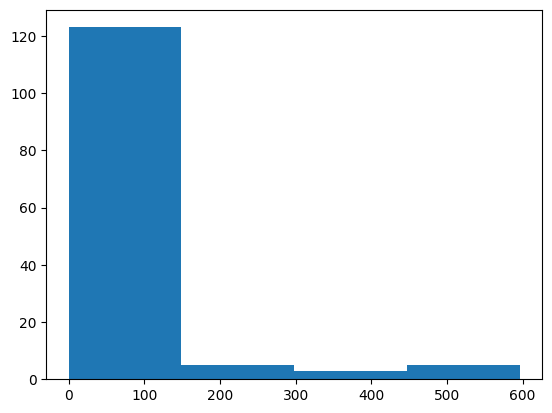

In [112]:
plt.hist(df_RRHH_ind_grouped['Absenteeism_hours'], bins=4)
plt.show()

In [113]:
df_abs_hours_hit_target = df_RRHH_ind_grouped[['ID','Absenteeism_hours','Hit_target']].copy()
df_abs_hours_hit_target

,ID,Absenteeism_hours,Hit_target
0,1,121,95.0
1,2,25,92.0
2,3,482,96.0
3,4,0,95.0
4,5,104,93.0
...,...,...,...
131,132,3,98.0
132,133,3,92.0
133,134,8,93.0
134,135,8,92.0


In [116]:
df_abs_hours_hit_target['category'] = pd.cut(
    df_abs_hours_hit_target['Absenteeism_hours'],
    bins=[0, 8, 40, float('inf')],
    labels=['<= 8h', '9 - 40h', '>40h'],
    include_lowest=True,
    right=True
)

- <= 8h       hasta una jornada laboral
- 9 - 40h     entre más de 1 día y hasta una semana laboral
- 41 - 120h   ausencias acumuladas medias-altas
- >120h       ausencias acumuladas muy altas

In [117]:
df_abs_hours_hit_target.groupby('category', observed=True)['Absenteeism_hours'].agg(
    n='count',
    min='min',
    max='max'
)

,n,min,max
category,,,
<= 8h,99,0,8
9 - 40h,16,16,40
>40h,21,42,596


In [118]:
abs_hours_categories = ['<= 8h', '9 - 40h', '>40h']

abs_hours_groups = [
    df_abs_hours_hit_target.loc[
        df_abs_hours_hit_target['category'] == category,
        'Hit_target'
    ]
    for category in abs_hours_categories
]

kruskal_wallis_test(
    *abs_hours_groups,
    alpha=0.05,
    group_names=abs_hours_categories
)

Descriptive statistics:


,group,n,mean,median,std,min,max,q1,q3,iqr
0,<= 8h,99,94.474747,95.0,3.818172,81.0,100.0,92.50,97.000,4.500
1,9 - 40h,16,94.125000,95.0,4.213075,81.0,99.0,92.75,96.125,3.375
2,>40h,21,94.880952,95.0,1.588275,91.0,98.0,94.00,96.000,2.000



---- Kruskal-Wallis test ----
Number of groups: 3
Degrees of freedom: 2
Alpha: 0.05
H statistic: 0.0661282283244977
P-value: 0.9674765286533925
Critical value X²U: 5.99146454710798

---- Interpretation using p-value ----
The p-value is larger than alpha 0.05, so the result is not significant.
Fail to reject the null hypothesis: there is no statistically significant difference between groups.

---- Interpretation using H statistic ----
The Kruskal-Wallis H statistic is smaller than the critical value.
Fail to reject the null hypothesis.


**Seasons y Months no se puede hacer así porque no son observaciones independientes???**

## Modelo de regresión lineal mixto (completo, df_RRHH)

### Para cada uno de los grupos de las otras variables

In [ ]:
df_RRHH.columns